# Run this complete setup cell

In [1]:
import pandas as pd
import numpy as np
import pandas_gbq

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------------
# 1. LOAD DATA FROM BIGQUERY
# -----------------------------------------

query = """
SELECT *
FROM `amplified-alpha-463610-c8.ecommerce_ml.session_features`
"""

df = pandas_gbq.read_gbq(
    query,
    project_id="amplified-alpha-463610-c8",
    dialect="standard"
)

print("Loaded:", df.shape)

Downloading: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████|
Loaded: (359603, 18)


# 2. Recreate feature engineering

In [4]:
data = df.copy()

data["session_date"] = pd.to_datetime(
    data["session_date"]
)

# Binary behavioral features
data["has_cart"] = (
    data["add_to_cart_5min"] > 0
).astype(int)

data["has_checkout"] = (
    data["begin_checkout_5min"] > 0
).astype(int)

data["has_product_view"] = (
    data["product_views_5min"] > 0
).astype(int)

data["has_product_click"] = (
    data["product_clicks_5min"] > 0
).astype(int)

data["is_returning_user"] = (
    1 - data["is_new_user"]
)

# Ratio features
data["product_views_per_page"] = (
    data["product_views_5min"]
    /
    data["page_views_5min"].replace(0, np.nan)
)

data["click_per_product_view"] = (
    data["product_clicks_5min"]
    /
    data["product_views_5min"].replace(0, np.nan)
)

data["cart_per_product_view"] = (
    data["add_to_cart_5min"]
    /
    data["product_views_5min"].replace(0, np.nan)
)

ratio_cols = [
    "product_views_per_page",
    "click_per_product_view",
    "cart_per_product_view"
]

data[ratio_cols] = (
    data[ratio_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Date features
data["day_of_week"] = (
    data["session_date"].dt.dayofweek
)

data["is_weekend"] = (
    data["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

# 3. Define model features

In [5]:
numeric_features = [
    "total_events_5min",
    "page_views_5min",
    "product_views_5min",
    "product_clicks_5min",
    "add_to_cart_5min",
    "begin_checkout_5min",
    "search_events_5min",
    "is_returning_user",
    "has_cart",
    "has_checkout",
    "has_product_view",
    "has_product_click",
    "product_views_per_page",
    "click_per_product_view",
    "cart_per_product_view",
    "is_weekend"
]

categorical_features = [
    "device_category",
    "operating_system",
    "traffic_source",
    "traffic_medium"
]

feature_columns = (
    numeric_features
    + categorical_features
)

for col in categorical_features:
    data[col] = (
        data[col]
        .fillna("unknown")
        .astype(str)
    )

# 4. Recreate the exact time split

In [6]:
train = data[
    data["session_date"] <= "2020-12-15"
].copy()

validation = data[
    (data["session_date"] >= "2020-12-16")
    &
    (data["session_date"] <= "2021-01-07")
].copy()

test = data[
    data["session_date"] >= "2021-01-08"
].copy()

X_train = train[feature_columns]
y_train = train["target"]

X_val = validation[feature_columns]
y_val = validation["target"]

X_test = test[feature_columns]
y_test = test["target"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (184148, 20)
Validation: (83529, 20)
Test: (91926, 20)


# 5. Recreate the preprocessing pipeline

In [7]:
preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

# 6. Recreate the selected Random Forest

In [8]:
rf_unweighted = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_unweighted.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


# 7. Verify everything exists

In [9]:
print(
    "rf_unweighted:",
    "rf_unweighted" in globals()
)

print(
    "X_train:",
    "X_train" in globals()
)

print(
    "X_test:",
    "X_test" in globals()
)

print(
    "preprocessor:",
    "preprocessor" in globals()
)

rf_unweighted: True
X_train: True
X_test: True
preprocessor: True


# 8. Now return to SHAP

In [10]:
preprocessor_final = (
    rf_unweighted
    .named_steps["preprocessor"]
)

rf_classifier = (
    rf_unweighted
    .named_steps["classifier"]
)

feature_names = (
    preprocessor_final
    .get_feature_names_out()
)

print(
    "Transformed features:",
    len(feature_names)
)

Transformed features: 36


In [13]:
import joblib
import shap

In [14]:
rf_unweighted = joblib.load(
    "models/random_forest.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/random_forest.pkl'

In [15]:
print("rf_unweighted" in globals())

True


In [16]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    rf_unweighted,
    "models/random_forest.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [17]:
print(
    os.path.exists(
        "models/random_forest.pkl"
    )
)

True


In [18]:
print(
    os.path.abspath(
        "models/random_forest.pkl"
    )
)

/Users/souravkumar/Downloads/User Conversion Prediction/notebooks/models/random_forest.pkl


In [19]:
import joblib

rf_unweighted = joblib.load(
    "models/random_forest.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [20]:
print("rf_unweighted" in globals())

True


In [21]:
preprocessor_final = (
    rf_unweighted.named_steps["preprocessor"]
)

rf_classifier = (
    rf_unweighted.named_steps["classifier"]
)

feature_names = (
    preprocessor_final.get_feature_names_out()
)

print(
    "Transformed features:",
    len(feature_names)
)

Transformed features: 36


In [22]:
X_shap_original = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

X_shap_transformed = preprocessor_final.transform(
    X_shap_original
)

if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

print("Original shape:", X_shap_original.shape)
print("Transformed shape:", X_shap_transformed.shape)

Original shape: (2000, 20)
Transformed shape: (2000, 36)


In [23]:
explainer = shap.TreeExplainer(
    rf_classifier
)

shap_values_raw = explainer.shap_values(
    X_shap_transformed
)

In [24]:
if isinstance(shap_values_raw, list):
    # Older SHAP versions
    shap_values = shap_values_raw[1]

elif (
    isinstance(shap_values_raw, np.ndarray)
    and shap_values_raw.ndim == 3
):
    # Newer SHAP versions:
    # samples × features × classes
    shap_values = shap_values_raw[:, :, 1]

else:
    shap_values = shap_values_raw

print("SHAP shape:", shap_values.shape)

SHAP shape: (2000, 36)


In [25]:
mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.head(15)

,feature,mean_abs_shap
0,num__total_events_5min,0.004793
2,num__product_views_5min,0.003936
7,num__is_returning_user,0.003166
1,num__page_views_5min,0.002896
10,num__has_product_view,0.002683
12,num__product_views_per_page,0.001949
4,num__add_to_cart_5min,0.001926
14,num__cart_per_product_view,0.001777
8,num__has_cart,0.001510
5,num__begin_checkout_5min,0.001173


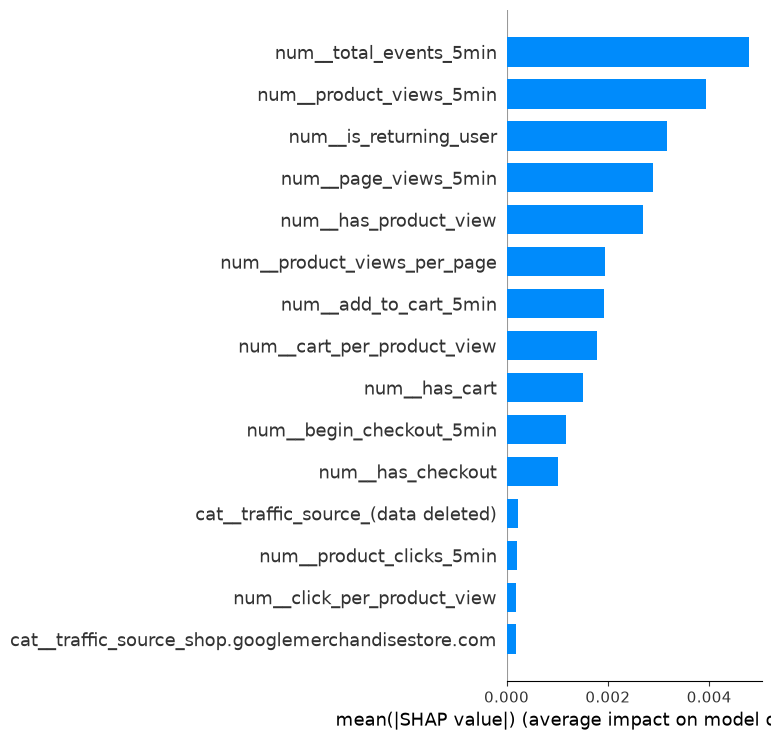

In [26]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

# 1. SHAP beeswarm plot

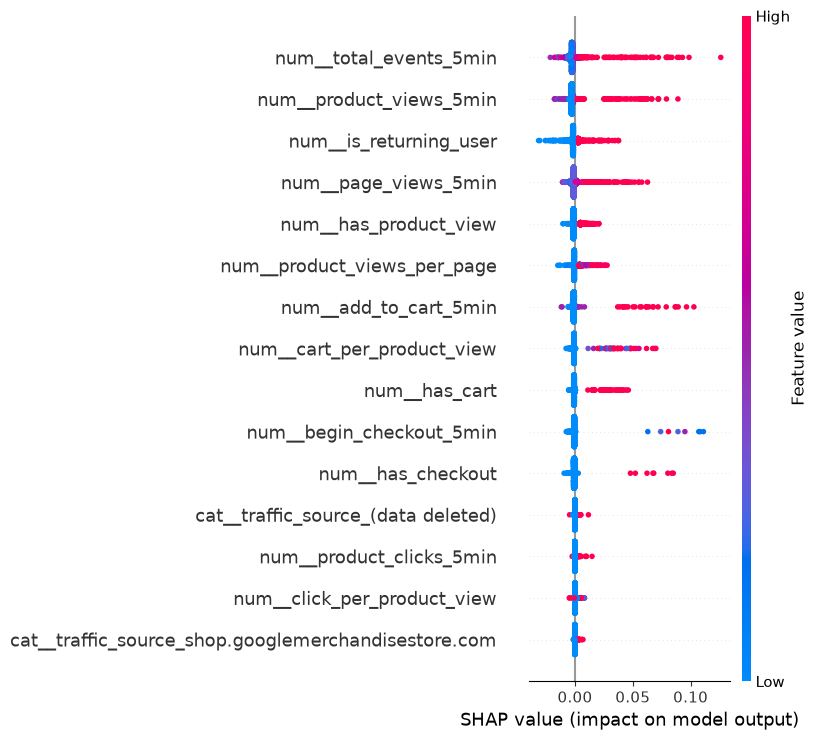

In [27]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    max_display=15
)

# 2. Clean the feature names

In [28]:
clean_feature_names = [
    name.replace("num__", "")
        .replace("cat__", "")
    for name in feature_names
]

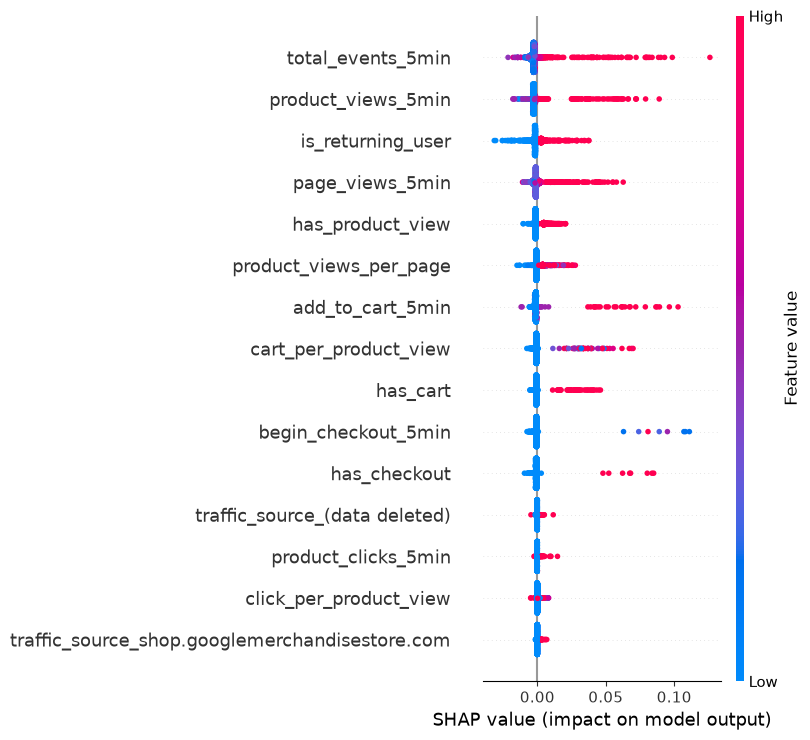

In [29]:
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=clean_feature_names,
    max_display=15
)

# 3. Explain one High-Intent session

In [30]:
rf_test_raw_prob = rf_unweighted.predict_proba(
    X_test
)[:, 1]

In [31]:
high_position = np.argmax(
    rf_test_raw_prob
)

X_high = X_test.iloc[
    [high_position]
]

print("Raw RF score:",
      rf_test_raw_prob[high_position])

print(X_high.T)

Raw RF score: 0.6788921811629844
                          180581
total_events_5min             51
page_views_5min               13
product_views_5min             7
product_clicks_5min            0
add_to_cart_5min               7
begin_checkout_5min            2
search_events_5min             0
is_returning_user              0
has_cart                       1
has_checkout                   1
has_product_view               1
has_product_click              0
product_views_per_page  0.538462
click_per_product_view       0.0
cart_per_product_view        1.0
is_weekend                     1
device_category           mobile
operating_system             Web
traffic_source            google
traffic_medium           organic


In [32]:
X_high_transformed = preprocessor_final.transform(
    X_high
)

if hasattr(X_high_transformed, "toarray"):
    X_high_transformed = (
        X_high_transformed.toarray()
    )

In [33]:
high_shap_raw = explainer.shap_values(
    X_high_transformed
)

In [34]:
if isinstance(high_shap_raw, list):

    high_shap = high_shap_raw[1][0]

elif (
    isinstance(high_shap_raw, np.ndarray)
    and high_shap_raw.ndim == 3
):

    high_shap = high_shap_raw[
        0, :, 1
    ]

else:

    high_shap = high_shap_raw[0]

In [35]:
high_explanation = pd.DataFrame({
    "feature": clean_feature_names,
    "feature_value":
        X_high_transformed[0],
    "shap_value":
        high_shap
})

high_explanation["abs_shap"] = (
    high_explanation[
        "shap_value"
    ].abs()
)

high_explanation = (
    high_explanation
    .sort_values(
        "abs_shap",
        ascending=False
    )
)

high_explanation[
    [
        "feature",
        "feature_value",
        "shap_value"
    ]
].head(15)

,feature,feature_value,shap_value
0,total_events_5min,4.655578,0.135976
4,add_to_cart_5min,12.561258,0.114789
5,begin_checkout_5min,7.403337,0.081671
14,cart_per_product_view,5.957205,0.071904
9,has_checkout,8.274273,0.068393
2,product_views_5min,4.113119,0.054588
1,page_views_5min,3.153810,0.053952
8,has_cart,5.569076,0.041165
12,product_views_per_page,0.982645,0.020762
7,is_returning_user,-0.687404,-0.017828


In [37]:
low_position = np.argmin(
    rf_test_raw_prob
)

X_low = X_test.iloc[
    [low_position]
]

# 1. First inspect the original Low-Intent session

In [38]:
print("Raw RF probability:",
      rf_test_raw_prob[low_position])

X_low.T

Raw RF probability: 0.00020811137569749286


,164866
total_events_5min,3
page_views_5min,1
product_views_5min,0
product_clicks_5min,0
add_to_cart_5min,0
begin_checkout_5min,0
search_events_5min,0
is_returning_user,0
has_cart,0
has_checkout,0


# 2. Transform the session

In [39]:
X_low_transformed = preprocessor_final.transform(
    X_low
)

if hasattr(X_low_transformed, "toarray"):
    X_low_transformed = X_low_transformed.toarray()

print(X_low_transformed.shape)

(1, 36)


# 3. Calculate SHAP for this Low-Intent session

In [40]:
low_shap_raw = explainer.shap_values(
    X_low_transformed
)

In [41]:
if isinstance(low_shap_raw, list):

    low_shap = low_shap_raw[1][0]

elif (
    isinstance(low_shap_raw, np.ndarray)
    and low_shap_raw.ndim == 3
):

    low_shap = low_shap_raw[
        0, :, 1
    ]

else:

    low_shap = low_shap_raw[0]

In [42]:
print(low_shap.shape)

(36,)


In [43]:
low_explanation = pd.DataFrame({
    "feature": clean_feature_names,
    "feature_value": X_low_transformed[0],
    "shap_value": low_shap
})

low_explanation["abs_shap"] = (
    low_explanation["shap_value"].abs()
)

low_explanation = (
    low_explanation
    .sort_values(
        "abs_shap",
        ascending=False
    )
)

low_explanation[
    [
        "feature",
        "feature_value",
        "shap_value"
    ]
].head(15)

,feature,feature_value,shap_value
0,total_events_5min,-0.582492,-0.002867
2,product_views_5min,-0.349478,-0.002553
1,page_views_5min,-0.433437,-0.001884
7,is_returning_user,-0.687404,-0.001412
10,has_product_view,-0.507857,-0.001292
4,add_to_cart_5min,-0.131562,-0.000973
14,cart_per_product_view,-0.149489,-0.000766
12,product_views_per_page,-0.345593,-0.000672
8,has_cart,-0.179563,-0.000671
5,begin_checkout_5min,-0.102470,-0.000597


In [44]:
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [45]:
X_low.T

,164866
total_events_5min,3
page_views_5min,1
product_views_5min,0
product_clicks_5min,0
add_to_cart_5min,0
begin_checkout_5min,0
search_events_5min,0
is_returning_user,0
has_cart,0
has_checkout,0


In [46]:
print("HIGH INTENT — TOP REASONS")

display(
    high_explanation[
        ["feature", "shap_value"]
    ].head(10)
)

print("LOW INTENT — TOP REASONS")

display(
    low_explanation[
        ["feature", "shap_value"]
    ].head(10)
)

HIGH INTENT — TOP REASONS


,feature,shap_value
0,total_events_5min,0.135976
4,add_to_cart_5min,0.114789
5,begin_checkout_5min,0.081671
14,cart_per_product_view,0.071904
9,has_checkout,0.068393
2,product_views_5min,0.054588
1,page_views_5min,0.053952
8,has_cart,0.041165
12,product_views_per_page,0.020762
7,is_returning_user,-0.017828


LOW INTENT — TOP REASONS


,feature,shap_value
0,total_events_5min,-0.002867
2,product_views_5min,-0.002553
1,page_views_5min,-0.001884
7,is_returning_user,-0.001412
10,has_product_view,-0.001292
4,add_to_cart_5min,-0.000973
14,cart_per_product_view,-0.000766
12,product_views_per_page,-0.000672
8,has_cart,-0.000671
5,begin_checkout_5min,-0.000597


# 1. Save the final Random Forest

In [47]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    rf_unweighted,
    "models/random_forest.pkl"
)

print("Random Forest saved.")

Random Forest saved.


In [48]:
print(
    os.path.exists(
        "models/random_forest.pkl"
    )
)

True


In [49]:
from sklearn.isotonic import IsotonicRegression

# Random Forest probabilities on validation data
rf_val_prob_final = rf_unweighted.predict_proba(
    X_val
)[:, 1]

# Fit final calibrator
final_isotonic = IsotonicRegression(
    out_of_bounds="clip"
)

final_isotonic.fit(
    rf_val_prob_final,
    y_val
)

# Save calibrator
joblib.dump(
    final_isotonic,
    "models/isotonic_calibrator.pkl"
)

print("Isotonic calibrator saved.")

print(
    os.path.exists(
        "models/isotonic_calibrator.pkl"
    )
)

Isotonic calibrator saved.
True


In [50]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

rf_test_raw_prob = rf_unweighted.predict_proba(
    X_test
)[:, 1]

rf_test_calibrated_prob = final_isotonic.predict(
    rf_test_raw_prob
)

print(
    "Test ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            rf_test_calibrated_prob
        ),
        4
    )
)

print(
    "Test PR-AUC:",
    round(
        average_precision_score(
            y_test,
            rf_test_calibrated_prob
        ),
        4
    )
)

print(
    "Test Log Loss:",
    round(
        log_loss(
            y_test,
            rf_test_calibrated_prob
        ),
        4
    )
)

print(
    "Test Brier Score:",
    round(
        brier_score_loss(
            y_test,
            rf_test_calibrated_prob
        ),
        4
    )
)

print(
    "Test Conversion Rate:",
    round(
        y_test.mean() * 100,
        3
    ),
    "%"
)

Test ROC-AUC: 0.952
Test PR-AUC: 0.2577
Test Log Loss: 0.0314
Test Brier Score: 0.0076
Test Conversion Rate: 0.93 %


In [52]:
import json
import os

os.makedirs("reports", exist_ok=True)

final_results = {
    "test_roc_auc": 0.9520,
    "test_pr_auc": 0.2577,
    "test_log_loss": 0.0314,
    "test_brier_score": 0.0076,
    "test_conversion_rate_pct": 0.93,

    "lift_at_5_pct": 15.5098,
    "recall_at_5_pct": 77.5439,
    "conversion_at_5_pct": 14.4256,

    "lift_at_10_pct": 8.8193,
    "recall_at_10_pct": 88.1871,
    "conversion_at_10_pct": 8.2028,

    "high_intent_session_share_pct": 5.0,
    "high_intent_purchase_share_pct": 77.6608,
    "high_intent_conversion_pct": 14.4473,

    "campaign_break_even_uplift_pp": 0.594
}

with open(
    "reports/final_metrics.json",
    "w"
) as f:
    json.dump(
        final_results,
        f,
        indent=4
    )

print("Final metrics saved.")

Final metrics saved.


In [53]:
# Raw Random Forest scores on validation data
rf_val_raw_prob = rf_unweighted.predict_proba(
    X_val
)[:, 1]

# Thresholds based on validation score distribution
high_threshold = np.quantile(
    rf_val_raw_prob,
    0.95
)

medium_threshold = np.quantile(
    rf_val_raw_prob,
    0.80
)

print("High Intent threshold:", high_threshold)
print("Medium Intent threshold:", medium_threshold)

High Intent threshold: 0.059454816677425935
Medium Intent threshold: 0.004051771810520739


In [54]:
deployment_config = {
    "high_intent_raw_score_threshold": float(high_threshold),
    "medium_intent_raw_score_threshold": float(medium_threshold),
    "segment_logic": {
        "high": "raw_score >= high_threshold",
        "medium": "medium_threshold <= raw_score < high_threshold",
        "low": "raw_score < medium_threshold"
    }
}

with open(
    "models/deployment_config.json",
    "w"
) as f:
    json.dump(
        deployment_config,
        f,
        indent=4
    )

print("Deployment thresholds saved.")

Deployment thresholds saved.
